## Image Generation using Diffusion Transformer.

In [1]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### dataset

https://www.kaggle.com/datasets/srinivasac/flickr30k-dataset?

In [2]:
BASE_PATH = "data/flickr30k"

CAPTION_FILE = os.path.join(BASE_PATH, "captions.txt")
IMAGE_FOLDER = os.path.join(BASE_PATH, "images")

print("Caption file exists:", os.path.exists(CAPTION_FILE))
print("Image folder exists:", os.path.exists(IMAGE_FOLDER))

Caption file exists: True
Image folder exists: True


In [3]:
import csv

data = []
limit=12
with open(CAPTION_FILE, "r", encoding="utf-8") as f:
    reader = csv.reader(f)

    # Skip header
    next(reader)

    for i, row in enumerate(reader):
        if i >= limit:
            break
            
        # Safety check
        if len(row) < 2:
            continue
        
        image_name = row[0].strip()
        caption = row[1].strip()

        data.append({
            "image_name": image_name,
            "caption": caption
        })

print("Total rows:", len(data))

Total rows: 12


In [4]:
df = pd.DataFrame(data)

df.head()

,image_name,caption
0,1000092795.jpg,Two young guys with shaggy hair look at their ...
1,1000092795.jpg,"Two young , White males are outside near many ..."
2,1000092795.jpg,Two men in green shirts are standing in a yard .
3,1000092795.jpg,A man in a blue shirt standing in a garden .
4,1000092795.jpg,Two friends enjoy time spent together .


### Add full image path 

In [5]:
df["image_path"] = df["image_name"].apply(
    lambda x: os.path.join(IMAGE_FOLDER, x)
)

df.head()

,image_name,caption,image_path
0,1000092795.jpg,Two young guys with shaggy hair look at their ...,data/flickr30k\images\1000092795.jpg
1,1000092795.jpg,"Two young , White males are outside near many ...",data/flickr30k\images\1000092795.jpg
2,1000092795.jpg,Two men in green shirts are standing in a yard .,data/flickr30k\images\1000092795.jpg
3,1000092795.jpg,A man in a blue shirt standing in a garden .,data/flickr30k\images\1000092795.jpg
4,1000092795.jpg,Two friends enjoy time spent together .,data/flickr30k\images\1000092795.jpg


### Remove broken image paths

In [6]:
df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

print("After filtering:", len(df))

After filtering: 12


### Dataset visualization

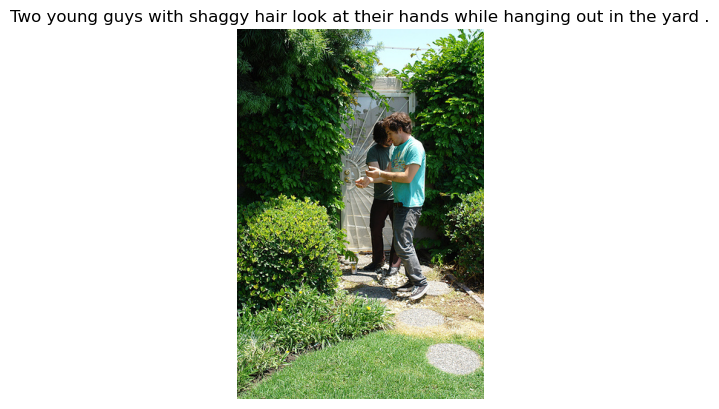

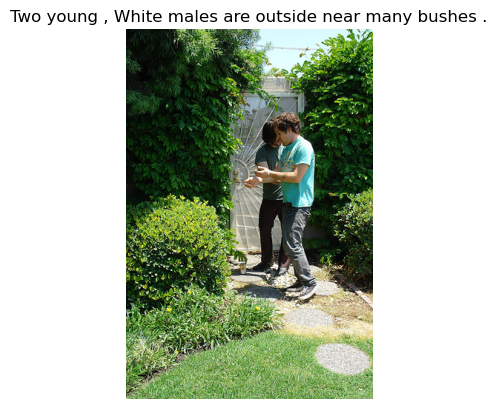

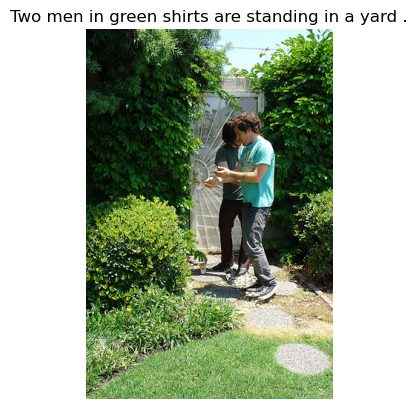

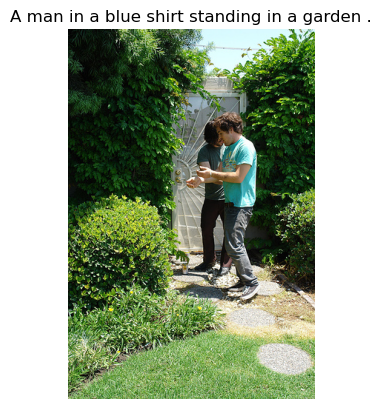

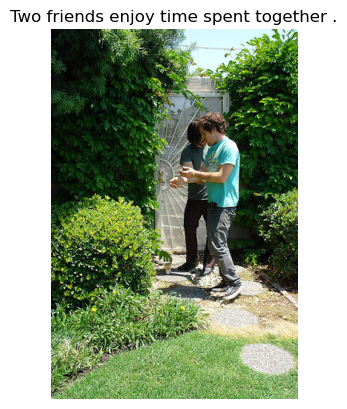

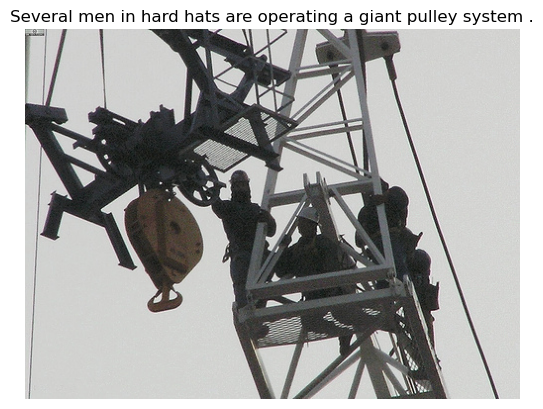

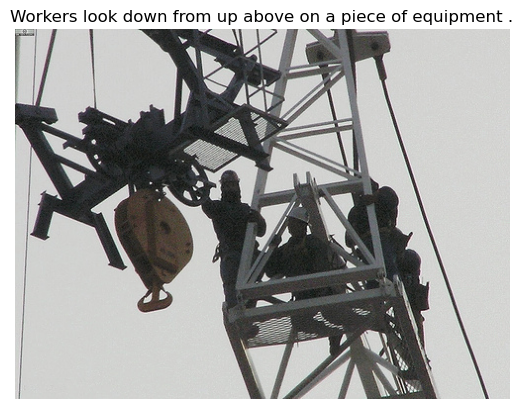

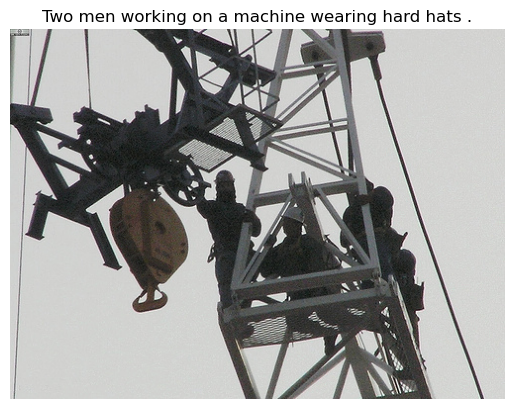

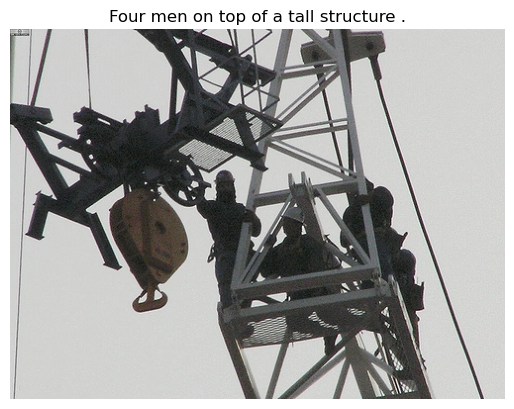

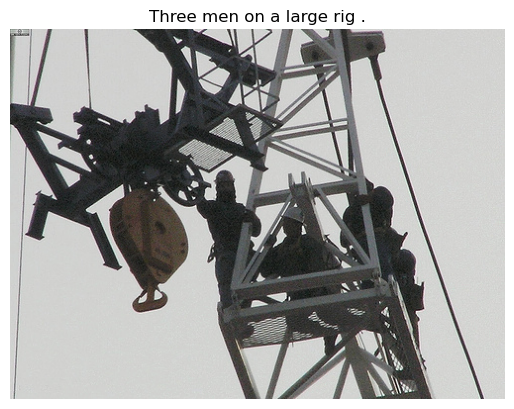

In [7]:
N = 10

for i in range(N):
    row = df.iloc[i]

    img = Image.open(row["image_path"])

    plt.imshow(img)
    plt.title(row["caption"])
    plt.axis("off")
    plt.show()

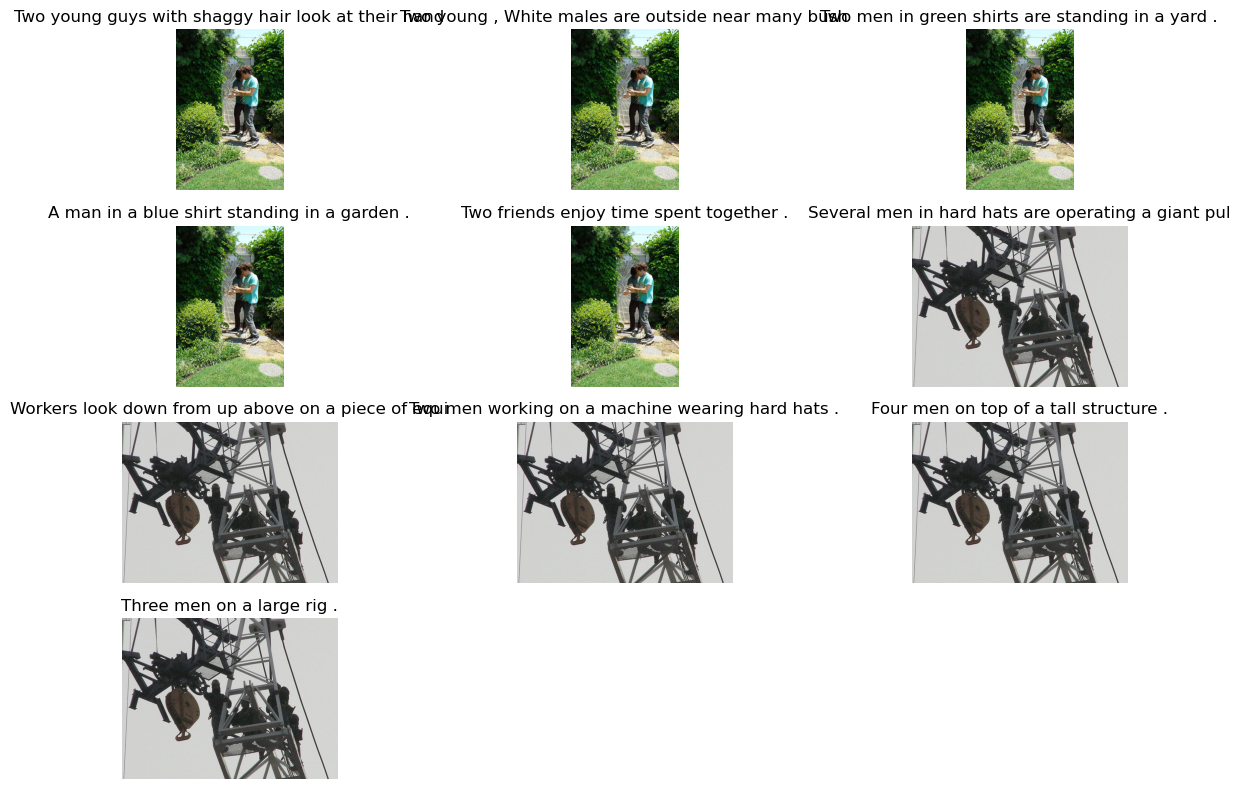

In [8]:
N = 10
cols = 3
rows = (N + cols - 1) // cols

plt.figure(figsize=(12, 8))

for i in range(N):
    row = df.iloc[i]
    img = Image.open(row["image_path"])

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(row["caption"][:50])  # shorten caption
    plt.axis("off")

plt.tight_layout()
plt.show()

### Build Vocabulary

In [9]:
# Collect all captions
captions = []
for item in data:
    captions.append(item["caption"].lower())

# Count words manually
word_freq = {}

for cap in captions:
    words = cap.split()
    for w in words:
        if w in word_freq:
            word_freq[w] += 1
        else:
            word_freq[w] = 1

# Special tokens
special_tokens = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]

# Build vocab list 
vocab_list = special_tokens.copy()

for word in word_freq:
    vocab_list.append(word)

# Create mappings
word2idx = {}
idx2word = {}

for i in range(len(vocab_list)):
    word2idx[vocab_list[i]] = i
    idx2word[i] = vocab_list[i]

print("Vocab size:", len(word2idx))

Vocab size: 85


In [10]:
word2idx

{'<PAD>': 0,
 '<UNK>': 1,
 '<SOS>': 2,
 '<EOS>': 3,
 'two': 4,
 'young': 5,
 'guys': 6,
 'with': 7,
 'shaggy': 8,
 'hair': 9,
 'look': 10,
 'at': 11,
 'their': 12,
 'hands': 13,
 'while': 14,
 'hanging': 15,
 'out': 16,
 'in': 17,
 'the': 18,
 'yard': 19,
 '.': 20,
 ',': 21,
 'white': 22,
 'males': 23,
 'are': 24,
 'outside': 25,
 'near': 26,
 'many': 27,
 'bushes': 28,
 'men': 29,
 'green': 30,
 'shirts': 31,
 'standing': 32,
 'a': 33,
 'man': 34,
 'blue': 35,
 'shirt': 36,
 'garden': 37,
 'friends': 38,
 'enjoy': 39,
 'time': 40,
 'spent': 41,
 'together': 42,
 'several': 43,
 'hard': 44,
 'hats': 45,
 'operating': 46,
 'giant': 47,
 'pulley': 48,
 'system': 49,
 'workers': 50,
 'down': 51,
 'from': 52,
 'up': 53,
 'above': 54,
 'on': 55,
 'piece': 56,
 'of': 57,
 'equipment': 58,
 'working': 59,
 'machine': 60,
 'wearing': 61,
 'four': 62,
 'top': 63,
 'tall': 64,
 'structure': 65,
 'three': 66,
 'large': 67,
 'rig': 68,
 'child': 69,
 'pink': 70,
 'dress': 71,
 'is': 72,
 'climbing

In [11]:
idx2word

{0: '<PAD>',
 1: '<UNK>',
 2: '<SOS>',
 3: '<EOS>',
 4: 'two',
 5: 'young',
 6: 'guys',
 7: 'with',
 8: 'shaggy',
 9: 'hair',
 10: 'look',
 11: 'at',
 12: 'their',
 13: 'hands',
 14: 'while',
 15: 'hanging',
 16: 'out',
 17: 'in',
 18: 'the',
 19: 'yard',
 20: '.',
 21: ',',
 22: 'white',
 23: 'males',
 24: 'are',
 25: 'outside',
 26: 'near',
 27: 'many',
 28: 'bushes',
 29: 'men',
 30: 'green',
 31: 'shirts',
 32: 'standing',
 33: 'a',
 34: 'man',
 35: 'blue',
 36: 'shirt',
 37: 'garden',
 38: 'friends',
 39: 'enjoy',
 40: 'time',
 41: 'spent',
 42: 'together',
 43: 'several',
 44: 'hard',
 45: 'hats',
 46: 'operating',
 47: 'giant',
 48: 'pulley',
 49: 'system',
 50: 'workers',
 51: 'down',
 52: 'from',
 53: 'up',
 54: 'above',
 55: 'on',
 56: 'piece',
 57: 'of',
 58: 'equipment',
 59: 'working',
 60: 'machine',
 61: 'wearing',
 62: 'four',
 63: 'top',
 64: 'tall',
 65: 'structure',
 66: 'three',
 67: 'large',
 68: 'rig',
 69: 'child',
 70: 'pink',
 71: 'dress',
 72: 'is',
 73: 'clim

### Encode Caption

In [12]:
def encode_caption(caption, word2idx, max_len=20):
    words = caption.lower().split()

    encoded = []

    # Add <SOS>
    encoded.append(word2idx["<SOS>"])

    for w in words:
        if w in word2idx:
            encoded.append(word2idx[w])
        else:
            encoded.append(word2idx["<UNK>"])

    # Add <EOS>
    encoded.append(word2idx["<EOS>"])

    # Padding / Truncation
    if len(encoded) < max_len:
        while len(encoded) < max_len:
            encoded.append(word2idx["<PAD>"])
    else:
        encoded = encoded[:max_len]

    return encoded

### Apply Encoding

In [13]:
max_len = 0
total_len = 0

for item in data:
    words = item["caption"].lower().split()
    length = len(words)

    total_len += length

    if length > max_len:
        max_len = length

avg_len = total_len / len(data)

print("Max length:", max_len)
print("Average length:", avg_len)

Max length: 18
Average length: 11.5


In [14]:
MAX_LEN = 25

for item in data:
    item["encoded_caption"] = encode_caption(
        item["caption"],
        word2idx,
        MAX_LEN
    )

print(data[0])

{'image_name': '1000092795.jpg', 'caption': 'Two young guys with shaggy hair look at their hands while hanging out in the yard .', 'encoded_caption': [2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 3, 0, 0, 0, 0, 0, 0]}


In [15]:
MAX_LEN = 25

df["encoded_caption"] = df["caption"].apply(
    lambda x: encode_caption(x, word2idx, MAX_LEN)
)

In [16]:
df.head()

,image_name,caption,image_path,encoded_caption
0,1000092795.jpg,Two young guys with shaggy hair look at their ...,data/flickr30k\images\1000092795.jpg,"[2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ..."
1,1000092795.jpg,"Two young , White males are outside near many ...",data/flickr30k\images\1000092795.jpg,"[2, 4, 5, 21, 22, 23, 24, 25, 26, 27, 28, 20, ..."
2,1000092795.jpg,Two men in green shirts are standing in a yard .,data/flickr30k\images\1000092795.jpg,"[2, 4, 29, 17, 30, 31, 24, 32, 17, 33, 19, 20,..."
3,1000092795.jpg,A man in a blue shirt standing in a garden .,data/flickr30k\images\1000092795.jpg,"[2, 33, 34, 17, 33, 35, 36, 32, 17, 33, 37, 20..."
4,1000092795.jpg,Two friends enjoy time spent together .,data/flickr30k\images\1000092795.jpg,"[2, 4, 38, 39, 40, 41, 42, 20, 3, 0, 0, 0, 0, ..."


### Attention Mask

In [17]:
def create_mask(encoded, pad_idx):
    mask = []
    for token in encoded:
        if token == pad_idx:
            mask.append(0)
        else:
            mask.append(1)
    return mask

for item in data:
    item["attention_mask"] = create_mask(
        item["encoded_caption"],
        word2idx["<PAD>"]
    )

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

### Transforms

In [19]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),   # fixed size
    transforms.ToTensor(),           # [0,1]
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )  # → [-1, 1] (required for diffusion)
])

### Custom Dataset

In [20]:
class FlickrDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        img_path = row["image_path"]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Text
        caption = torch.tensor(row["encoded_caption"], dtype=torch.long)

        # Mask (if exists)
        if "attention_mask" in row:
            mask = torch.tensor(row["attention_mask"], dtype=torch.long)
        else:
            mask = (caption != 0).long()

        return {
            "image": image,
            "caption": caption,
            "mask": mask
        }

### Dataset

In [21]:
dataset = FlickrDataset(df, transform=transform)

print("Dataset size:", len(dataset))

Dataset size: 12


In [22]:
sample = dataset[0]

print(type(sample["image"]))
print(sample["image"].shape)
print(sample["caption"].shape)
print(sample["mask"].shape)

<class 'torch.Tensor'>
torch.Size([3, 128, 128])
torch.Size([25])
torch.Size([25])


### DataLoader

In [23]:
BATCH_SIZE = 1

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

In [24]:
batch = next(iter(dataloader))

print("Image shape:", batch["image"].shape)
print("Caption shape:", batch["caption"].shape)
print("Mask shape:", batch["mask"].shape)

Image shape: torch.Size([1, 3, 128, 128])
Caption shape: torch.Size([1, 25])
Mask shape: torch.Size([1, 25])


# Transfomer Architecture

Text:   
→ Tokenize → Embedding → Pos → Transformer Encoder → text_tokens (B, L, D)   

Image:  
→ Resize → Normalize → image (B, 3, H, W)    
→ Sample timestep t   
→ Add Noise → noisy_image x_t (B, 3, H, W)   

Time:   
→ t → Time Embedding → time_tokens (B, D)   

Diffusion Model (UNet):    
→ Conv In (x_t)   
→ Down Blocks (Encoder)    
→ Mid Block    
 
→ Cross-Attn (image_features ↔ text_tokens)   
→ + Time Conditioning (time_tokens added)    

→ Up Blocks (Decoder with skip connections)   
→ Conv Out    

Output:     
→ predicted_noise ε̂ (B, 3, H, W)    

Training:    
→ Loss = MSE(ε̂, ε)    

Inference:    
→ x_T ~ N(0, I)    
→ Iterative Denoising (t → 0)    
→ Generated Image x_0    

## Encoder Architecture

In [25]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import math

### Embedings and Positional encoding

In [26]:
class TextEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_dim, max_len=512):
        super().__init__()

        # Token embedding
        self.token_embedding = nn.Embedding(vocab_size, emb_dim)

        # Positional Encoding (precomputed)
        pe = torch.zeros(max_len, emb_dim)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, emb_dim, 2) * (-math.log(10000.0) / emb_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as buffer (not trainable)
        self.register_buffer("pos_encoding", pe.unsqueeze(0))  # (1, T, D)

    def forward(self, x):
        B, T = x.size()

        # Token embedding
        emb = self.token_embedding(x)   # (B, T, D)

        # Add positional encoding
        emb = emb + self.pos_encoding[:, :T, :].to(emb.device)

        return emb

In [27]:
vocab_size = len(word2idx)
emb_dim = 512
MAX_LEN = 25
BATCH_SIZE = 4

In [28]:
vocab_size

85

In [29]:
model = TextEmbedding(vocab_size, emb_dim, max_len=MAX_LEN)
dummy_input = torch.randint(0, vocab_size, (BATCH_SIZE, MAX_LEN))
output = model(dummy_input)

# Print shapes
print("Input shape:", dummy_input.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([4, 25])
Output shape: torch.Size([4, 25, 512])


In [30]:
import matplotlib.pyplot as plt

In [31]:
def plot_pos(max_len = 50 ,embdim = 64 ,cmap='Spectral'):

    # build PE from formula
    pe = torch.zeros(max_len, embdim)
    position = torch.arange(0, max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, embdim, 2) * (-math.log(10000.0) / embdim)
    )
    
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    
    # plot
    plt.figure(figsize=(18, 8))
    plt.imshow(pe.T, aspect="auto", cmap=cmap)
    plt.colorbar(label="PE value")
    plt.xlabel("Position")
    plt.ylabel("Embedding dimension")
    plt.title("Sinusoidal Positional Encoding ")
    plt.show()


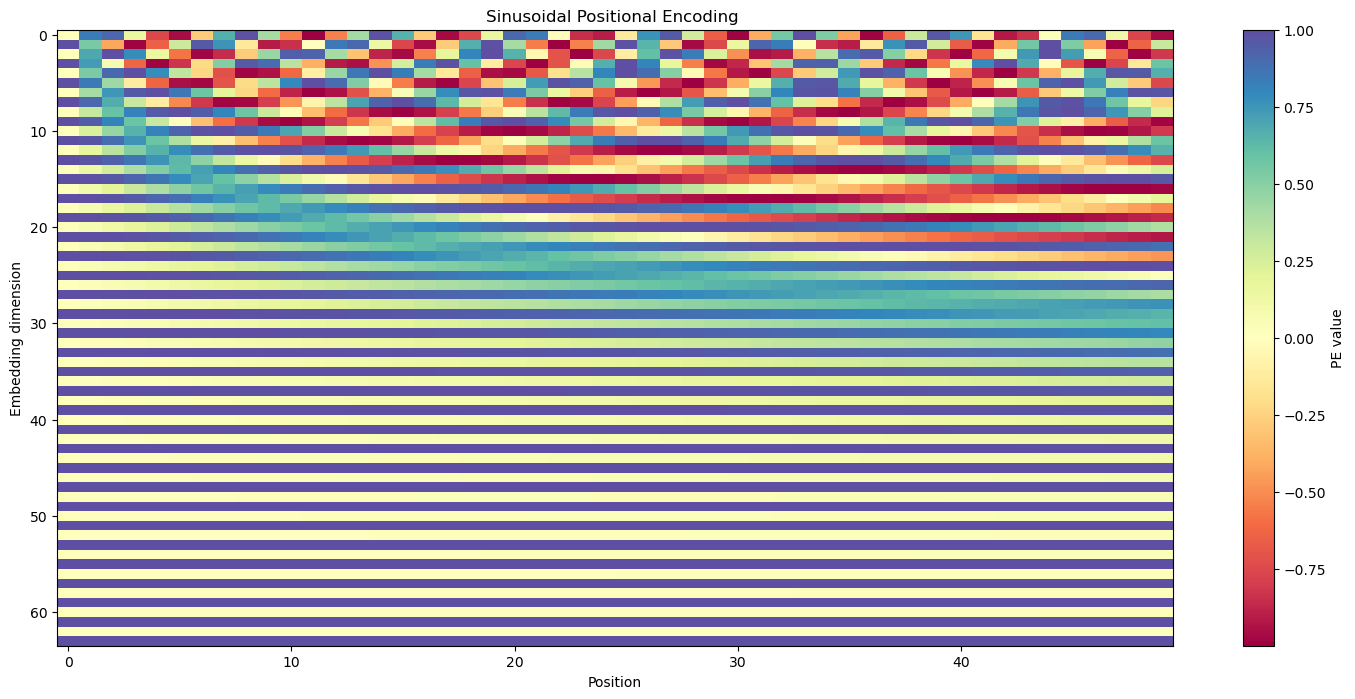

In [32]:
plot_pos()

## MultiHeadSelfAttention

In [33]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, emb_dim, num_heads):
        super().__init__()

        assert emb_dim % num_heads == 0, "emb_dim must be divisible by num_heads"

        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads

        # Linear projections
        self.q_proj = nn.Linear(emb_dim, emb_dim)
        self.k_proj = nn.Linear(emb_dim, emb_dim)
        self.v_proj = nn.Linear(emb_dim, emb_dim)

        # Output projection
        self.out_proj = nn.Linear(emb_dim, emb_dim)

    def forward(self, x, mask=None):
        B, T, D = x.shape

        # Project
        Q = self.q_proj(x)  # (B, T, D)
        K = self.k_proj(x)
        V = self.v_proj(x)

        # Split heads
        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)  # (B, H, T, Hd)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # (B, H, T, T)

        # Apply mask (for PAD)
        if mask is not None:
            # mask: (B, T) → (B, 1, 1, T)
            mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # Softmax
        attn = torch.softmax(scores, dim=-1)

        # Weighted sum
        out = torch.matmul(attn, V)  # (B, H, T, Hd)

        # Merge heads
        out = out.transpose(1, 2).contiguous().view(B, T, D)

        # Final projection
        out = self.out_proj(out)

        return out

## FeedForward Network

In [34]:
class FeedForward(nn.Module):
    def __init__(self, emb_dim, hidden_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, emb_dim)
        )

    def forward(self, x):
        return self.net(x)

## EncoderBlock

In [35]:
class EncoderBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, hidden_dim):
        super().__init__()

        self.norm1 = nn.LayerNorm(emb_dim)
        self.attn = MultiHeadSelfAttention(emb_dim, num_heads)

        self.norm2 = nn.LayerNorm(emb_dim)
        self.ffn = FeedForward(emb_dim, hidden_dim)

    def forward(self, x, mask=None):
        # --- Self Attention block ---
        x = x + self.attn(self.norm1(x), mask)

        # --- FeedForward block ---
        x = x + self.ffn(self.norm2(x))

        return x

## Diffusion Model Architecture

### Time Embedding

In [36]:
class TimeEmbedding(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * 4),
            nn.GELU(),
            nn.Linear(emb_dim * 4, emb_dim)
        )

        self.emb_dim = emb_dim

    def forward(self, t):
        # t: (B,)
        half_dim = self.emb_dim // 2

        freqs = torch.exp(
            -math.log(10000) * torch.arange(0, half_dim) / half_dim
        ).to(t.device)

        args = t[:, None].float() * freqs[None]

        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        return self.mlp(emb)  # (B, D)

In [37]:
class TimeEmbedding(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * 4),
            nn.GELU(),
            nn.Linear(emb_dim * 4, emb_dim)
        )

        self.emb_dim = emb_dim

    def forward(self, t):
        half_dim = self.emb_dim // 2
    
        device = t.device  # keep reference once
    
        freqs = torch.exp(
            -math.log(10000) * torch.arange(0, half_dim, device=device) / half_dim
        )
    
        args = t[:, None].float() * freqs[None]
    
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    
        return self.mlp(emb)

### ResNet Block

In [38]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)

        self.act = nn.GELU()

        self.time_mlp = nn.Linear(time_dim, out_channels)

        # Residual connection
        if in_channels != out_channels:
            self.res_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.res_conv = nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.act(h)

        # Add time embedding
        t = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + t

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)

        return h + self.res_conv(x)

### Cross-Attention

In [39]:
class CrossAttention(nn.Module):
    def __init__(self, img_dim, text_dim, num_heads):
        super().__init__()

        self.text_proj = nn.Linear(text_dim, img_dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=img_dim,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x, text_tokens):
        B, C, H, W = x.shape

        x_flat = x.view(B, C, H * W).permute(0, 2, 1)

        text_tokens = self.text_proj(text_tokens)

        out, _ = self.attn(
            query=x_flat,
            key=text_tokens,
            value=text_tokens
        )

        out = out.permute(0, 2, 1).view(B, C, H, W)

        return out + x

### Down Block

In [40]:
class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, num_heads, text_dim=512):
        super().__init__()

        self.res = ResBlock(in_ch, out_ch, time_dim)

        self.attn = CrossAttention(
            img_dim=out_ch,
            text_dim=text_dim,
            num_heads=num_heads
        )

        self.downsample = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)

    def forward(self, x, t_emb, text_tokens):
        x = self.res(x, t_emb)
        x = self.attn(x, text_tokens)

        skip = x
        x = self.downsample(x)

        return x, skip

### Up Block

In [41]:
class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, num_heads, text_dim=512):
        super().__init__()

        # upsample reduces channels BEFORE concat logic fix
        self.upsample = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, 4, stride=2, padding=1)

        self.res = ResBlock(in_ch, out_ch, time_dim)

        self.attn = CrossAttention(
            img_dim=out_ch,
            text_dim=text_dim,
            num_heads=num_heads
        )

    def forward(self, x, skip, t_emb, text_tokens):

        x = self.upsample(x)

        # FIX: ensure same spatial size
        if x.shape[-2:] != skip.shape[-2:]:
            skip = torch.nn.functional.interpolate(skip, size=x.shape[-2:])

        x = torch.cat([x, skip], dim=1)

        x = self.res(x, t_emb)
        x = self.attn(x, text_tokens)

        return x

### Mid Block

In [42]:
class MidBlock(nn.Module):
    def __init__(self, ch, time_dim, num_heads, text_dim=512):
        super().__init__()

        self.res1 = ResBlock(ch, ch, time_dim)

        self.attn = CrossAttention(
            img_dim=ch,
            text_dim=text_dim,
            num_heads=num_heads
        )

        self.res2 = ResBlock(ch, ch, time_dim)

    def forward(self, x, t_emb, text_tokens):
        x = self.res1(x, t_emb)
        x = self.attn(x, text_tokens)
        x = self.res2(x, t_emb)
        return x

## UNet - Diffusion Model

In [43]:
class UNet(nn.Module):
    def __init__(self, base_ch=128, time_dim=512, num_heads=8, text_dim=512):
        super().__init__()

        # Time embedding
        self.time_emb = TimeEmbedding(time_dim)

        # Input conv
        self.conv_in = nn.Conv2d(3, base_ch, 3, padding=1)

        # DOWN 
        self.down1 = DownBlock(
            in_ch=base_ch,
            out_ch=base_ch * 2,
            time_dim=time_dim,
            num_heads=num_heads,
            text_dim=text_dim
        )

        self.down2 = DownBlock(
            in_ch=base_ch * 2,
            out_ch=base_ch * 4,
            time_dim=time_dim,
            num_heads=num_heads,
            text_dim=text_dim
        )

        #  MID 
        self.mid = MidBlock(
            ch=base_ch * 4,
            time_dim=time_dim,
            num_heads=num_heads,
            text_dim=text_dim
        )

        #  UP 
        self.up1 = UpBlock(
            in_ch=base_ch * 4 + base_ch * 4,
            out_ch=base_ch * 2,
            time_dim=time_dim,
            num_heads=num_heads,
            text_dim=text_dim
        )

        self.up2 = UpBlock(
            in_ch=base_ch * 2 + base_ch * 2,
            out_ch=base_ch,
            time_dim=time_dim,
            num_heads=num_heads,
            text_dim=text_dim
        )

        # Output
        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_act = nn.GELU()
        self.conv_out = nn.Conv2d(base_ch, 3, 3, padding=1)

    def forward(self, x, t, text_tokens):

        t_emb = self.time_emb(t)

        x = self.conv_in(x)

        # Down
        x, skip1 = self.down1(x, t_emb, text_tokens)
        x, skip2 = self.down2(x, t_emb, text_tokens)

        # Mid
        x = self.mid(x, t_emb, text_tokens)

        # Up
        x = self.up1(x, skip2, t_emb, text_tokens)
        x = self.up2(x, skip1, t_emb, text_tokens)

        # Output noise prediction
        x = self.out_norm(x)
        x = self.out_act(x)
        x = self.conv_out(x)

        return x

B = 2
H = W = 256
L = 25
D = 512

x = torch.randn(B, 3, H, W)                  # noisy image
t = torch.randint(0, 1000, (B,))            # timesteps
text_tokens = torch.randn(B, L, D)          # encoder output

model = UNet(base_ch=128,time_dim=512,num_heads=8)

out = model(x, t, text_tokens)

print("Input image:", x.shape)
print("Timesteps:", t.shape)
print("Text tokens:", text_tokens.shape)
print("Output:", out.shape)

## Diffusion Transformer

In [44]:
class DiffusionTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        text_emb_dim=512,
        enc_layers=4,
        enc_heads=8,
        unet_base=128,
        time_dim=512,
        unet_heads=8
    ):
        super().__init__()

        #  TEXT SIDE 
        self.text_embed = TextEmbedding(vocab_size, text_emb_dim)

        self.encoder_stack = nn.ModuleList([
            EncoderBlock(
                emb_dim=text_emb_dim,
                num_heads=enc_heads,
                hidden_dim=text_emb_dim * 4
            )
            for _ in range(enc_layers)
        ])

        #  IMAGE DIFFUSION SIDE 
        self.unet = UNet(
            base_ch=unet_base,
            time_dim=time_dim,
            num_heads=unet_heads,
            text_dim=text_emb_dim
        )

    #  TEXT ENCODER 
    def encode_text(self, text, mask=None):
        x = self.text_embed(text)

        for layer in self.encoder_stack:
            x = layer(x, mask)

        return x  # (B, L, D)

    #  FORWARD 
    def forward(self, image, t, text, mask=None):

        # Encode text
        text_tokens = self.encode_text(text, mask)

        # UNet diffusion step
        noise_pred = self.unet(image, t, text_tokens)

        return noise_pred

In [45]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [46]:
my_model = DiffusionTransformer(
    vocab_size=vocab_size,
    text_emb_dim=1024,
    enc_layers=8,
    enc_heads=8,
    unet_base=256,
    time_dim=1024,
    unet_heads=8).to(device)

### Record parameters

In [47]:
my_model

DiffusionTransformer(
  (text_embed): TextEmbedding(
    (token_embedding): Embedding(85, 1024)
  )
  (encoder_stack): ModuleList(
    (0-7): 8 x EncoderBlock(
      (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
      )
      (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=4096, out_features=4096, bias=True)
          (3): GELU(approximate='none')
          (4): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )

In [48]:
for name, param in my_model.named_parameters():
    print(name, param.requires_grad)

text_embed.token_embedding.weight True
encoder_stack.0.norm1.weight True
encoder_stack.0.norm1.bias True
encoder_stack.0.attn.q_proj.weight True
encoder_stack.0.attn.q_proj.bias True
encoder_stack.0.attn.k_proj.weight True
encoder_stack.0.attn.k_proj.bias True
encoder_stack.0.attn.v_proj.weight True
encoder_stack.0.attn.v_proj.bias True
encoder_stack.0.attn.out_proj.weight True
encoder_stack.0.attn.out_proj.bias True
encoder_stack.0.norm2.weight True
encoder_stack.0.norm2.bias True
encoder_stack.0.ffn.net.0.weight True
encoder_stack.0.ffn.net.0.bias True
encoder_stack.0.ffn.net.2.weight True
encoder_stack.0.ffn.net.2.bias True
encoder_stack.0.ffn.net.4.weight True
encoder_stack.0.ffn.net.4.bias True
encoder_stack.1.norm1.weight True
encoder_stack.1.norm1.bias True
encoder_stack.1.attn.q_proj.weight True
encoder_stack.1.attn.q_proj.bias True
encoder_stack.1.attn.k_proj.weight True
encoder_stack.1.attn.k_proj.bias True
encoder_stack.1.attn.v_proj.weight True
encoder_stack.1.attn.v_proj.b

In [49]:
total_params = sum(p.numel() for p in my_model.parameters())
print(total_params)

376278531


In [50]:
trainable_params = sum(p.numel() for p in my_model.parameters() if p.requires_grad)
print(trainable_params)

376278531


In [51]:
num_param_tensors = len(list(my_model.named_parameters()))
print(num_param_tensors)

261


In [52]:
all_trainable = all(p.requires_grad for p in my_model.parameters())
print("All parameters trainable:", all_trainable)

All parameters trainable: True


## Training

In [53]:
# time saving

In [54]:
def train_diffusion(
    model,
    dataloader,
    optimizer,
    loss_fn,
    noise_scheduler,
    device="cuda",
    epochs=5
):
    model

    for epoch in range(epochs):
        model.train()

        total_loss = 0

        print(f"\nEpoch [{epoch+1}/{epochs}]")

        for batch_idx, batch in enumerate(dataloader):

            #  DATA 
            image = batch["image"].to(device)            # (B, 3, 256, 256)
            text = batch["caption"].to(device)           # (B, L)
            mask = batch["mask"].to(device)              # (B, L)

            B = image.shape[0]

            #  SAMPLE TIMESTEP 
            t = torch.randint(
                0,
                noise_scheduler.num_timesteps,
                (B,),
                device=device
            )

            #  ADD NOISE 
            noise = torch.randn_like(image)
            x_t = noise_scheduler.add_noise(image, noise, t)

            #  FORWARD 
            noise_pred = model(x_t, t, text, mask)   # (B, 3, 256, 256)

            #  LOSS 
            loss = loss_fn(noise_pred, noise)

            #  BACKPROP 
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            #  LOGGING 
            if batch_idx % 1 == 0:
                print(
                    f"Batch [{batch_idx+1}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f}"
                )

        #  EPOCH SUMMARY 
        avg_loss = total_loss / len(dataloader)

        print(
            f"Epoch Summary → Loss: {avg_loss:.4f}"
        )

In [55]:
class SimpleNoiseScheduler:
    def __init__(self, num_timesteps=1000):
        self.num_timesteps = num_timesteps

        betas = torch.linspace(1e-4, 0.02, num_timesteps)
        alphas = 1.0 - betas
        self.alphas_cumprod = torch.cumprod(alphas, dim=0)

    def add_noise(self, x0, noise, t):
        device = x0.device
        self.alphas_cumprod = self.alphas_cumprod.to(device)

        alpha_t = self.alphas_cumprod[t].view(-1, 1, 1, 1)

        return torch.sqrt(alpha_t) * x0 + torch.sqrt(1 - alpha_t) * noise

In [56]:
noise_scheduler = SimpleNoiseScheduler(num_timesteps=1000)

In [57]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(my_model.parameters(), lr=5e-6)

In [58]:
%%time
train_diffusion(
    model=my_model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    noise_scheduler=noise_scheduler,
    device=device,
    epochs=100
)


Epoch [1/100]
Batch [1/12] Loss: 1.1666
Batch [2/12] Loss: 1.1075
Batch [3/12] Loss: 1.0183
Batch [4/12] Loss: 0.9409
Batch [5/12] Loss: 0.8712
Batch [6/12] Loss: 0.8356
Batch [7/12] Loss: 1.1000
Batch [8/12] Loss: 0.7446
Batch [9/12] Loss: 0.7350
Batch [10/12] Loss: 0.7389
Batch [11/12] Loss: 0.6527
Batch [12/12] Loss: 0.6340
Epoch Summary → Loss: 0.8788

Epoch [2/100]
Batch [1/12] Loss: 0.5944
Batch [2/12] Loss: 0.6318
Batch [3/12] Loss: 0.5665
Batch [4/12] Loss: 0.7162
Batch [5/12] Loss: 0.5063
Batch [6/12] Loss: 0.4765
Batch [7/12] Loss: 0.9490
Batch [8/12] Loss: 0.4363
Batch [9/12] Loss: 0.4236
Batch [10/12] Loss: 0.4078
Batch [11/12] Loss: 0.3749
Batch [12/12] Loss: 0.9726
Epoch Summary → Loss: 0.5880

Epoch [3/100]
Batch [1/12] Loss: 0.4525
Batch [2/12] Loss: 0.6059
Batch [3/12] Loss: 0.3306
Batch [4/12] Loss: 0.3287
Batch [5/12] Loss: 0.4068
Batch [6/12] Loss: 0.2889
Batch [7/12] Loss: 0.6080
Batch [8/12] Loss: 1.1521
Batch [9/12] Loss: 0.4992
Batch [10/12] Loss: 0.2684
Batch 

In [73]:
%%time
train_diffusion(
    model=my_model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    noise_scheduler=noise_scheduler,
    device=device,
    epochs=200
)


Epoch [1/200]
Batch [1/12] Loss: 0.0246
Batch [2/12] Loss: 0.0249
Batch [3/12] Loss: 0.0225
Batch [4/12] Loss: 0.0286
Batch [5/12] Loss: 0.0240
Batch [6/12] Loss: 0.0591
Batch [7/12] Loss: 0.0245
Batch [8/12] Loss: 0.0257
Batch [9/12] Loss: 0.0221
Batch [10/12] Loss: 0.0293
Batch [11/12] Loss: 0.0231
Batch [12/12] Loss: 0.0400
Epoch Summary → Loss: 0.0290

Epoch [2/200]
Batch [1/12] Loss: 0.0345
Batch [2/12] Loss: 0.0221
Batch [3/12] Loss: 0.1211
Batch [4/12] Loss: 0.0262
Batch [5/12] Loss: 0.1481
Batch [6/12] Loss: 0.0872
Batch [7/12] Loss: 0.0265
Batch [8/12] Loss: 0.0250
Batch [9/12] Loss: 0.0890
Batch [10/12] Loss: 0.0223
Batch [11/12] Loss: 0.0289
Batch [12/12] Loss: 0.0270
Epoch Summary → Loss: 0.0548

Epoch [3/200]
Batch [1/12] Loss: 0.0556
Batch [2/12] Loss: 0.0228
Batch [3/12] Loss: 0.0303
Batch [4/12] Loss: 0.0240
Batch [5/12] Loss: 0.0208
Batch [6/12] Loss: 0.0374
Batch [7/12] Loss: 0.0193
Batch [8/12] Loss: 0.0219
Batch [9/12] Loss: 0.0531
Batch [10/12] Loss: 0.1386
Batch 

## Inference

In [74]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [116]:
@torch.no_grad()
def generate_image(
    model,
    image_size,
    text,
    mask,
    noise_scheduler,
    device="cuda",
    steps=30
):
    model.eval()

    text = text.to(device)
    mask = mask.to(device)

    # FIX: correct text encoding flow
    text_tokens = model.text_embed(text)

    for layer in model.encoder_stack:
        text_tokens = layer(text_tokens, mask)

    x = torch.randn(1, 3, image_size, image_size).to(device)

    timesteps = torch.linspace(
        noise_scheduler.num_timesteps - 1,
        0,
        steps,
        dtype=torch.long,
        device=device
    )

    for t in timesteps:

        t = t.unsqueeze(0)

        noise_pred = model.unet(x, t, text_tokens)

        alpha_t = noise_scheduler.alphas_cumprod.to(device)[t]

        x = (x - (1 - alpha_t).sqrt() * noise_pred) / alpha_t.sqrt()

    return x

In [128]:
#EXP
@torch.no_grad()
def generate_image(
    model,
    image_size,
    text,
    mask,
    noise_scheduler,
    device="cuda",
    steps=30
):
    model.eval()

    text = text.to(device)
    mask = mask.to(device)

    x = torch.randn(1, 3, image_size, image_size).to(device)

    timesteps = torch.linspace(
        noise_scheduler.num_timesteps - 1,
        0,
        steps,
        dtype=torch.long,
        device=device
    )

    for t in timesteps:

        t = t.unsqueeze(0)

        noise_pred = model(x, t, text, mask)

        alpha_t = noise_scheduler.alphas_cumprod.to(device)[t]

        x = noise_pred

    return x

### plot image

In [129]:
def show_image(tensor_img):

    img = tensor_img.detach().cpu().squeeze(0)
    img = img.permute(1, 2, 0)

    # normalize safely
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

#### Test

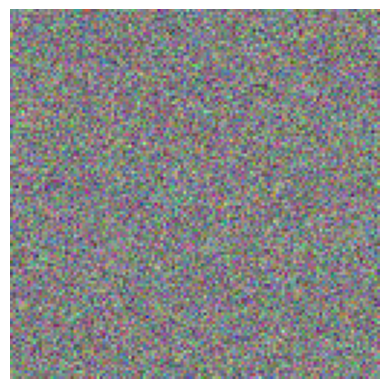

In [130]:
show_image(torch.randn(1, 3, 128, 128))

In [131]:
B = 1
L = 25
D = 512


# fake token IDs (IMPORTANT: LONG, not float)
text = torch.randint(0, vocab_size, (B, L)).to(device)

# mask (1 = valid, 0 = pad)
mask = torch.ones(B, L, dtype=torch.long).to(device)

In [134]:
%%time
generated = generate_image(
    model=my_model,
    image_size=128,
    text=text,
    mask=mask,
    noise_scheduler=noise_scheduler,
    device=device,
    steps=100
)

print("Generated:", generated.shape)

Generated: torch.Size([1, 3, 128, 128])
CPU times: total: 4.08 s
Wall time: 1min 10s


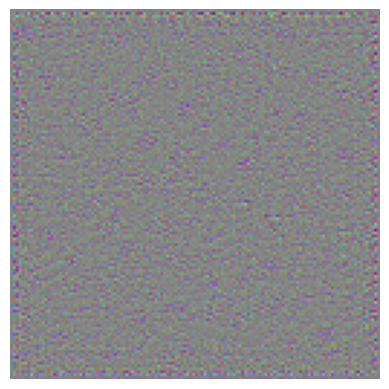

In [135]:
show_image(generated)

In [109]:
# real test

In [136]:
model.eval()
batch = next(iter(dataloader))   

image = batch["image"][0].to(device)        # (B, 3, 256, 256)
text = batch["caption"][0].to(device)       # (B, L)
mask = batch["mask"][0].to(device) 

image = image.unsqueeze(0)   # (1, 3, 256, 256)
text  = text.unsqueeze(0)    # (1, L)
mask  = mask.unsqueeze(0)    # (1, L)# (B, L)

print("Image:", image.shape)
print("Text:", text)
print("Mask:", mask)

Image: torch.Size([1, 3, 128, 128])
Text: tensor([[ 2,  4, 38, 39, 40, 41, 42, 20,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0]], device='cuda:0')
Mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0]], device='cuda:0')


In [137]:
t = torch.randint(
    0,
    noise_scheduler.num_timesteps,
    (image.shape[0],),
    device=device
)

with torch.no_grad():
    out = my_model(image, t, text, mask)

print("Output shape:", out.shape)

Output shape: torch.Size([1, 3, 128, 128])


In [138]:
%%time
generated = generate_image(
    model=my_model,
    image_size=128,
    text=text,
    mask=mask,
    noise_scheduler=noise_scheduler,
    device=device,
    steps=5000
)

print("Generated shape:", generated.shape)

Generated shape: torch.Size([1, 3, 128, 128])
CPU times: total: 3min 16s
Wall time: 59min 51s


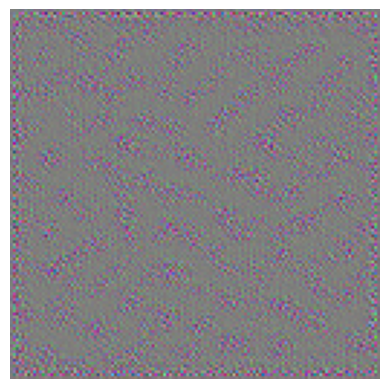

In [139]:
show_image(generated)

# save models

In [98]:
from pathlib import Path
root=Path('models')
root.mkdir(exist_ok=True)
path1= root / "Deffision_Image.pth"


In [99]:
torch.save(my_model,path1)